# **Esame del 28 giugno 2024**

- Non si possono consultare libri, note, ed ogni altro materiale o persone durante
l’esame ad eccezione delle funzioni Python fornite.

- Risolvere i seguenti esercizi con l’ausilio di Python.

- La durata del compito è di 90 minuti.

- Questo esame ha 3 domande, per un totale di 30/30 punti + 1 extra.

- Svolgere gli esercizi marcati con **[T]** su fogli protocollo, indicando: nome, cognome, codice persona
e data

# **Esercizio 1 (punti 10+1)**

Si consideri la seguente matrice:

\begin{gather*}
      A =
    \frac{1}{h}
    \begin{bmatrix}
        2  & -1     & 0  & 0  & 0  & \ldots & 0  \\
        -1 & 2      & -1 & 0  & 0  & \ldots & 0  \\
        0  & -1     & 2  & -1 & 0  & \ldots & 0  \\
        \ldots                                   \\
        0  & \ldots & 0  & 0  & -1 & 2      & -1 \\
        0  & \ldots & 0  & 0  & 0  & -1     & 2
    \end{bmatrix}
\end{gather*}

dove $h=\frac{1}{n}$ ed $n$ è il numero di righe e colonne della matrice.

#### **(1a) (3 punti) [P+T]**  
Enunciare le condizioni sufficienti per l'esistenza della fattorizzazione LU di una matrice. Scegliere $n=5$ e verificare con Matlab che la matrice data soddisfa una di tali condizioni.

In [1]:
# importazione pacchetti
import scipy.linalg
import numpy as np
from scipy.linalg import eigvals
from functions import fwsub, bksub
import matplotlib.pyplot as plt

##### **Soluzione.** 

 Data una matrice $A\in\mathbb{R}^{n\times n}$ non singolare la fattorizzazione LU esiste ed è unica 
- *se e solo se* tutte le sotto-matrici principali $A_i$ di ordine $i=1\ldots n-1$ sono non singolari (necessaria e sufficiente)
- se è simmetrica definita positiva
- se è a dominanza diagonale stretta per righe o colonne.
 
Costruiamo la matrice:

In [2]:
# dimensione matrice
n = 5
h = 1 / n
# vettore di tutti 1 di dimensione n
R = np.ones(n)
# costruzione matrice A
A = (
    2 / h * np.diag(R)
    - 1 / h * np.diag(R[0 : n - 1], -1)
    - 1 / h * np.diag(R[0 : n - 1], 1)
)

Verifichiamo che è SDP:

In [3]:
if (A == A.T).all():
    print("matrice simmetrica")

if np.min(eigvals(A)) > 0:
    print("definita positiva")

matrice simmetrica
definita positiva


#### **(1b) (3 punti) [P]**  
Data la soluzione esatta $\mathbf{x}=[1,\,1\,\ldots,1]^\top$ costruire il termine noto $\mathbf{b}$ e risolvere il sistema lineare $A\mathbf{x}=\mathbf{b}$ utilizzando i) la fattorizzazione LU  da scipy.linalg  ii) i metodi di sostituzione in avanti e all'indietro implementati nelle funzioni fornite. Verificare se è stato effettuato il pivoting.

##### **Soluzione.**

Consideriamo il seguente codice.

In [4]:
P, L, U = scipy.linalg.lu(A)

if np.all(P == np.eye(n)):
    print("P = I, no pivoting")
else:
    print("P != I, pivoting")

x_ex = np.ones(n)
b = A @ x_ex

y = fwsub(L, P.T @ b)
x = bksub(U, y)
print(x)

P = I, no pivoting
[1. 1. 1. 1. 1.]


Osserviamo che in questo caso non è stato effettuato il pivoting. La soluzione numerica, in questo caso, è praticamente identica alla soluzione esatta.

#### **(1c) (4 punti) [P+T]**  
Ripetere la costruzione del termine noto e la soluzione del sistema per $n=10$, $20$,    $40$ e $80$. Per ognuno dei casi calcolare la norma dell'errore *relativo* e il condizionamento della matrice e rappresentarli su due grafici in scala logaritmica. Commentare i risultati alla luce della teoria. (utilizzare le funzioni da np.linalg per condizionamento e norma di vettore).

##### **Soluzione.** 

Ripetiamo i passi al punto precedente in un ciclo al variare di n.

[48.37415007870845, 178.06427461086068, 680.6170700217425, 2658.4065019158797]
[2.808666774861361e-16, 3.1006841635969763e-16, 1.1796609430749332e-15, 2.5251472946894126e-15]


Text(0.5, 1.0, 'Condizionamento')

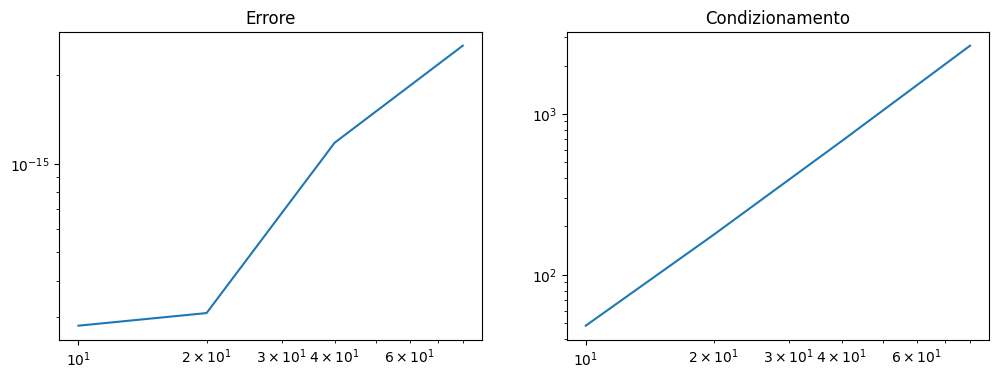

In [5]:
err = []
cond = []
N = np.array([10, 20, 40, 80])
for n in N:
    h = 1 / n
    R = np.ones(n)
    A = (
        2 / h * np.diag(R)
        - 1 / h * np.diag(R[0 : n - 1], -1)
        - 1 / h * np.diag(R[0 : n - 1], 1)
    )
    P, L, U = scipy.linalg.lu(A)
    x_ex = np.ones(n)
    b = A @ x_ex
    y = fwsub(L, P.T @ b)
    x = bksub(U, y)
    cond.append(np.linalg.cond(A))
    err.append(np.linalg.norm(x - x_ex) / np.linalg.norm(x_ex))

print(cond)
print(err)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.loglog(N, err)
plt.title("Errore")
plt.subplot(1, 2, 2)
plt.loglog(N, cond)
plt.title("Condizionamento")

Dal grafico ottenuto osserviamo che per matrici di dimensioni maggiori l'errore cresce (leggermente) questo si spiega con l'aumento del numero di condizionamento della matrice, che tuttavia non è molto alto in questo caso.

#### **(1d) (1 punto - extra) [P+T]** 
Commentare l’andamento del condizionamento della matrice al variare di $n$ (o $h$). Cosa si osserva?

##### **Soluzione.** 


Sovrapponendo l'andamento di $n^2$ nel grafico in scala logaritmica osserviamo che il condizionamento cresce come $n^2$. E' un risultato che potevamo aspettarci notando che la matrice fornita è una matrice di *stiffness* in 1D, il cui condizionamento dipende dal passo di griglia $h$, in particolare $K(A)\propto h^{-2}$.       

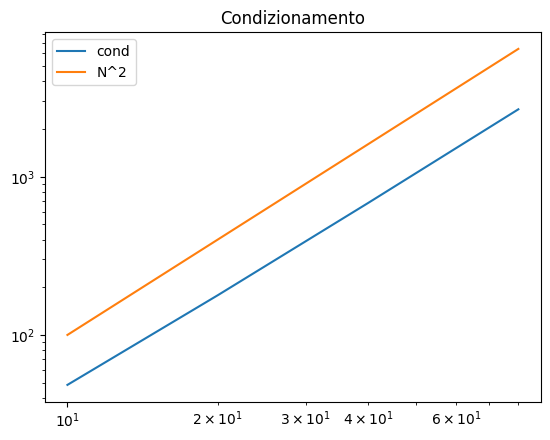

In [6]:
plt.loglog(N, cond, label="cond")
plt.loglog(N, N * N, label="N^2")
plt.legend()
plt.title("Condizionamento")
plt.show()

# **Esercizio 2 (10 punti)**


Si considerino i seguenti integrali definiti
\begin{gather*}
    I = \int_a^{b} f_i(x) dx
    \quad \text{per} \quad
    f_1(x) = \sin(\pi x)
        \quad \text{e} \quad
    f_2(x) = -x^3+x+1
\end{gather*}


#### **(2a) (3 punti) [P+T]** 
Calcolare i valori esatti degli integrali $I_1$ e $I_2$ con $a=0$ e $b=1$.

##### **Soluzione.** 

Definiamo le funzioni, l'intervallo e l'integranda per poter calcolare il valore esatto dei due integrali.

In [7]:
from functions import simpcomp
import numpy as np
import matplotlib.pyplot as plt

In [8]:
a = 0
b = 1
f1 = lambda x: np.sin(np.pi * x)
F1 = lambda x: -1.0 / np.pi * np.cos(np.pi * x)
I1 = F1(b) - F1(a)
print(I1)
f2 = lambda x: -(x**3) + x + 1
F2 = lambda x: -(x**4) / 4.0 + x**2 / 2 + x
I2 = F2(b) - F2(a)
print(I2)

0.6366197723675814
1.25


#### **(2b) (3 punti) [T]** 

Introdurre il metodo di quadratura di Simpson nella sua versione composita. Qual'è l'ordine di accuratezza per tale metodo? E il suo grado di esattezza?

##### **Soluzione.**

La formula di Simpson, in cui approssimiamo $I$ utilizzando il valore della funzione in tre punti, è   data da
\begin{gather*}
    I \approx I_s = \frac{b-a}{6} \left[ f(a) + 4 f\left( m \right) +
        f(b) \right],
\end{gather*}
dove $m = 0.5 (a+b)$, il cui errore è dato da
\begin{gather*}
    |E_s|\leq \frac{(b-a)^5}{16\cdot 180} \max_{x\in[a,b]} |f^{(iv)} (x)|.
\end{gather*}

Nell'integrazione composita suddividiamo l'intervallo $[a,b]$ in $n$ sotto-intervalli, dove, per $i=1,\ldots,n$, ogni intervallo \`e dato da $I_i = [x_{i-1}, x_i]$ con $x_i= a+ iH$ e dove $H=(b-a)/n$. Otteniamo così la formula di Simpson composita risulta data da
\begin{gather*}
    I_s^c = \frac{H}{6} \sum_{i=1}^n \left[ f(x_{i-1}) + 4 f\left( \frac{x_{i-1}
            + x_i}{2}\right) + f(x_i)\right].
\end{gather*}
L'errore  è dato da $|E_s^c| \leq c H^4$. L'ordine di accuratezza per Simpson è pari a 4, mentre il grado di esattezza è pari a  3.

#### **(2c) (4 punti) [P]** 
Usando la funzione *simpcomp* (fornita in functions.py) calcolare un'approssimazione di $I_1$ e $I_2$ suddividendo l'intervallo di integrazione  in $N = [10,20,40,80]$ sotto-intervalli.
Calcolare l'errore ottenuto nei due casi e rappresentarlo in scala logaritmica. Commentare i risultati ottenuti alla luce della teoria.

##### **Soluzione.**

Consideriamo il seguente condice.

[2.1595548974628898e-06, 1.3467474291317671e-07, 8.412535223989437e-09, 5.257110302636647e-10]
[0.0, 2.220446049250313e-16, 0.0, 0.0]


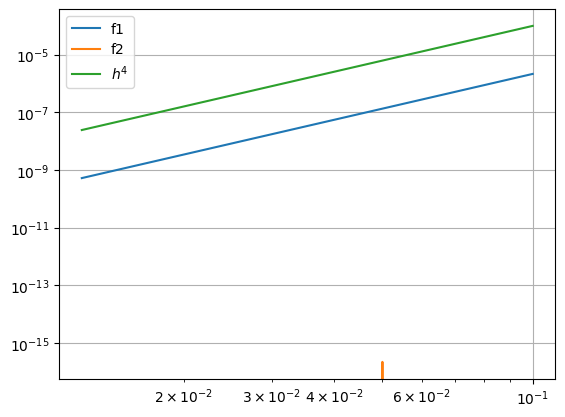

In [9]:
N = np.array([10, 20, 40, 80])

err1 = []
err2 = []

for n in N:
    Is1 = simpcomp(f1, a, b, n)
    err1.append(np.abs(Is1 - I1))
    Is2 = simpcomp(f2, a, b, n)
    err2.append(np.abs(Is2 - I2))

print(err1)
print(err2)
plt.figure()
plt.loglog(1.0 / N, err1, label="f1")
plt.loglog(1.0 / N, err2, label="f2")
plt.loglog(1.0 / N, 1.0 / (N**4), label="$h^4$")
plt.grid()
plt.legend()

Possiamo osservare che, come previsto dalla teoria, l'errore decresce ordine 4 nel caso della funzione $f_1$. Tuttavia, per la funzione $f_2$, otteniamo un errore costante e praticamente nullo. Questo è dovuto al fatto che la funzione scelta è di grado 3, e il metodo di Simpson è esatto per tali funzioni.

# **Esercizio 3 (10 punti)**

Assumendo $c > 0$, si consideri la seguente equazione di conservazione

$$\begin{cases}
\partial_t c + \partial_x(-c) = 0\qquad x\in(0,5),\;t\in(0,T]\\
c(0,x) = \begin{cases}
0\qquad x<3 \\
1\qquad 3\leq x\leq 4 \\
0\qquad x>4 
\end{cases}\\
c(t,0) = 0\qquad t\in(0,T]
\end{cases}$$

dove il tempo finale è pari a $T = 2$.

#### **(3a) (3 punti) [T]** 

Illustrare il flusso numerico Upwind per la soluzione di leggi di conservazione con il metodo dei volumi finiti. Verificare se il flusso Upwind è applicabile per il problema in esame.

##### **Soluzione.** 

Se il flusso $f(c)$ è monotono, ossia $f^\prime(c)>0$ (o $f^\prime(c)<0$) per per ogni valore di $c\in[c_m, c_M]$ dove $c_m$ e $c_M$ sono il massimo e minimo valore della condizione iniziale $c^0$, allora possiamo usare il cosiddetto flusso upwind definito sull'interfaccia $i+\frac{1}{2}$ fra la cella $i$ e la cella $i+1$ come
\begin{gather*}
    F^{UP}_{i+\frac{1}{2}}(c_i, c_{i+1}) =
    \begin{cases}
        f(c_i)  &  \mathrm{se}\, f^\prime(c)\geq0\, \forall c\in[c_i, c_{i+1}]\\
        f(c_{i+1}) & \mathrm{se}\, f^\prime(c)\leq0\, \forall c\in[c_i, c_{i+1}]
    \end{cases}.
\end{gather*}    
Nel caso in esame abbiamo $f(c)=-c$ e $f'(c)=-1$. In base ai dati iniziali forniti il valore minimo e massimo di $c$ sono rispettivamente $c_m=0$, $c_M=1$ e, per tali valori, la derivata prima della funzione flusso è sempre negativa quindi il flusso upwind è applicabile.

#### **(3b) (1 punti) [T]**  

Scegliere il valore $h=0.125$ costante per l'ampiezza delle celle. Calcolare quindi il massimo $\Delta t$ ammesso per il problema in esame e chiamare $\Delta t_{max}$ tale valore.

##### **Soluzione.**   

Per soddisfare la condizione CFL dobbiamo garantire che $\Delta t \max_{c\in(c_m,c_M)} |f'(c)|<h$. Con i valori scelti si ottiene $\Delta t_{max}=0.125/1=0.125$.

#### **(3c) (3 punti) [P+T]**  

Sia $N = T / \Delta t_{max}$, risolvere il problema utilizzando la function *fvsolve* fornita in *utils_solver_cl.py* utilizzando il metodo Upwind per $N$, $N-2$ e $2N$ passi temporali (attenzione: calcolare i $\Delta t$ corrispondenti!) e rappresentare le soluzioni ottenute usando la function *xtplot* fornita in *utils_plot_cl.py*. Cosa si osserva?

##### **Soluzione.**

Consideriamo il seguente codice

0.125


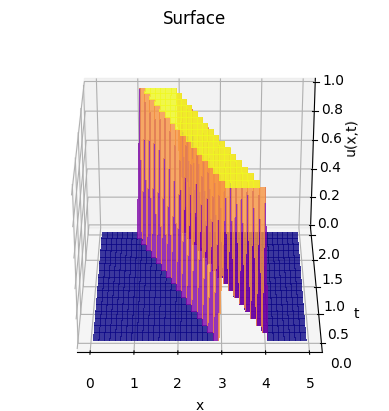

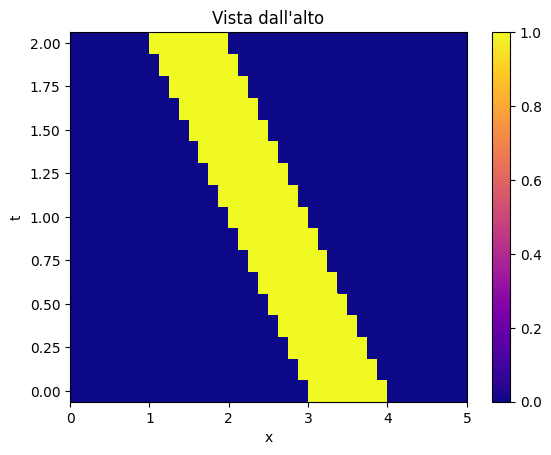

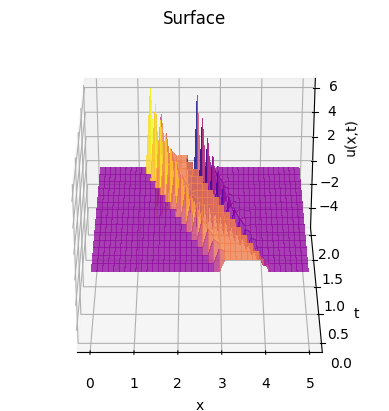

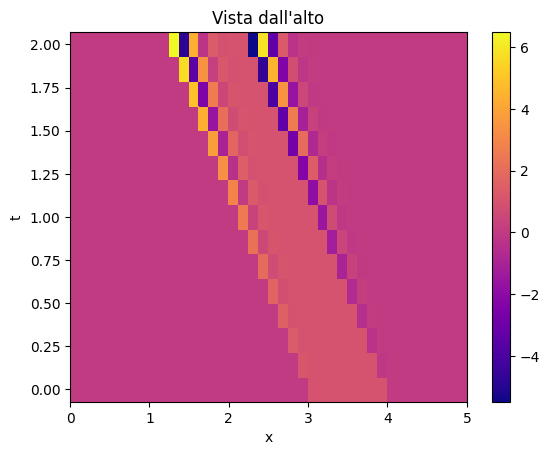

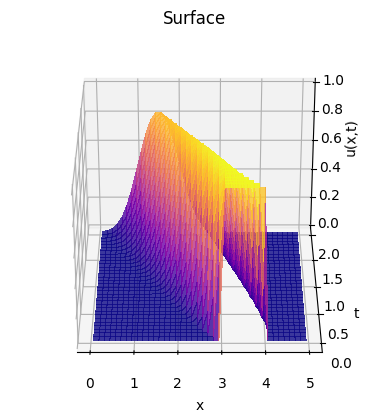

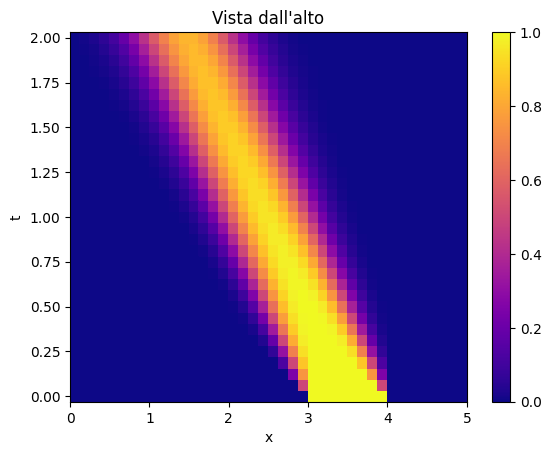

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import functions
from utilis_plot_cl import xtplot

# Dati del problema
u0 = lambda x: (x > 3) * (x < 4)
f = lambda c: -c
df = lambda c: -1

h = 0.125
dtlim = h / np.abs(df(1))
print(dtlim)
L = 5
T = 2
N = T / dtlim

# Soluzione per vari valori di N
for n in [N, N - 2, N * 2]:
    xc, t, u = functions.fvsolve(u0, f, df, L, T, h, T / n, "UPWIND")
    plt.figure()
    xtplot(xc, t, u, "surface")
    plt.show()

Osserviamo che per il passo  temporale ''limite'' la soluzione viene correttamente trasportata verso sinistra; per un passo temporale leggermente superiore al massimo consentito dalla CFL si osservano oscillazioni; per passi temporali minori si ha una soluzione corretta, con una maggiore diffusine numerica.

#### **(3d) (3 punti) [T]**

Calcolare la soluzione esatta del problema al tempo finale $t=T$ e confrontarla con i risultati ottenuti al punto precedente.

##### **Soluzione.** 

Si tratta di un problema di trasporto lineare, per cui la soluzione esatta è semplicemente
\begin{gather}
    c_e(t,x) = c_0(x-vt)
\end{gather}
dove $c_0$ è la condizione iniziale e, nel nostro caso, la velocità di trasporto è $v=-1$. Al tempo $t=T=2$ quindi otteniamo 
\begin{gather}
    c_e(2,x) =
    \begin{cases}
        0 & x < 1 \\
        1 & 1\leq x\leq 2\\
        0 & x>2
    \end{cases}
\end{gather}
Confrontando questa soluzione con le soluzioni numeriche si osserva che la velocità di trasporto è corretta, tuttavia la diffusione numerica può alterare il profilo della soluzione.